In [1]:
import Agents
import MarketsV02 as Markets

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import random

In [2]:
'''
def add_price_data(df, t):
    
    p_buy, p_sell = df
    
    for v, agent in enumerate(agent_list):
        p_buy[t][v] = agent.p_buy
        p_sell[t][v] = agent.p_sell
        
def add_quant_data(df, t):

    for v,agent in enumerate(agent_list):

        df[t][v] = agent.Q
    
def add_deficit_data(df, t):

    for v,agent in enumerate(agent_list):

        df[t][v] = agent.D
    
def add_money_data(df, t):
    
    for v,agent in enumerate(agent_list):

        df[t][v] = agent.M
'''

'\ndef add_price_data(df, t):\n    \n    p_buy, p_sell = df\n    \n    for v, agent in enumerate(agent_list):\n        p_buy[t][v] = agent.p_buy\n        p_sell[t][v] = agent.p_sell\n        \ndef add_quant_data(df, t):\n\n    for v,agent in enumerate(agent_list):\n\n        df[t][v] = agent.Q\n    \ndef add_deficit_data(df, t):\n\n    for v,agent in enumerate(agent_list):\n\n        df[t][v] = agent.D\n    \ndef add_money_data(df, t):\n    \n    for v,agent in enumerate(agent_list):\n\n        df[t][v] = agent.M\n'

In [3]:
'''
            
def market_supply_demand():
    supply0 = 0
    demand0 = 0
    for agent in agent_list:

        quants = scda.determine_market_quantity(agent)

        if quants[0] > 0:
            supply0 += quants[0]
        elif quants[0] < 0:
            demand0 += -quants[0]
            
    return supply0, demand0
'''

'\n            \ndef market_supply_demand():\n    supply0 = 0\n    demand0 = 0\n    for agent in agent_list:\n\n        quants = scda.determine_market_quantity(agent)\n\n        if quants[0] > 0:\n            supply0 += quants[0]\n        elif quants[0] < 0:\n            demand0 += -quants[0]\n            \n    return supply0, demand0\n'

In [4]:
class Experiment:

    def __init__(self, NA, NB, A_asks, A_bids, B_asks, B_bids, *, M=100., initialize_money='set', initialize_prices='set', supply=100., epsilon=0.01):

        self.n = 2

        self.N = NA + NB
        self.NA = NA
        self.NB = NB

        self.A_asks = A_asks
        self.A_bids = A_bids
        self.B_asks = B_asks
        self.B_bids = B_bids

        self.initialize_money = initialize_money
        self.initialize_prices = initialize_prices
        self.supply = supply
        self.M = M
        
        #print(self.M)

        self.epsilon=epsilon

        QA1 = supply
        QA2 = 0.

        QB1 = 0.
        QB2 = 0.

        cA1 = 0.
        cA2 = 0.

        cB1 = supply
        cB2 = 0

        QA_0 = np.array([QA1, QA2])
        QB_0 = np.array([QB1, QB2])

        self.QA = np.copy(QA_0)
        self.QB = np.copy(QB_0)

        self.cA = np.array([cA1, cA2])
        self.cB = np.array([cB1, cB2])

        self.DA = self.cA.copy()
        self.DB = self.cB.copy()

        self.agentA_list = [Agents.Agent(self.QA.copy(), self.DA.copy(), self.M, n_actions=1, input_dims=[1]) for v in range(self.NA)]
        self.agentB_list = [Agents.Agent(self.QB.copy(), self.DB.copy(), self.M, n_actions=1, input_dims=[1]) for v in range(self.NB)]

        self.agent_list = self.agentA_list + self.agentB_list
        
        #print(self.agent_list[0].M)

        self.M_dict = {}

        for agent in self.agent_list: 
            self.M_dict[agent] = np.random.uniform(self.M)
            
        #print(self.M)

    def reset(self):

        self.scda = Markets.SCDA(self.n, theta=0.005, gamma=1.0, epsilon=0.01, max_tries=self.N, M_min=0.01, peval='log_mean')
        self.ExchangeDict = {agent : 2 for agent in self.agent_list}
        for agent in self.agentA_list:

            if self.initialize_prices=='random':

                agent.p_buy  = np.random.uniform(agent.M, size=self.n)
                agent.p_sell = np.random.uniform(agent.M, size=self.n)

            else:
                agent.p_buy  = self.A_bids
                agent.p_sell = self.A_asks

        for agent in self.agentB_list:

            if self.initialize_prices=='random':
                agent.p_buy  = np.random.uniform(agent.M, size=self.n)
                agent.p_sell = np.random.uniform(agent.M, size=self.n)

            else:
                agent.p_buy  = self.B_bids
                agent.p_sell = self.B_asks

    def run_market(self, T):

        self.reset()

        # Setup data
        ME_df = np.zeros((T-1, self.n))
        QE_df = np.zeros((T-1, self.n))
        ntries_df = []

        # Run market
        for t in range(T-1):

            #supply_t, demand_t = market_supply_demand()

            # Market action occurs at half-time interval
            ME, QE, ntries = self.scda.run_exchange(self.ExchangeDict)

            # Reset quantities
            for agentA in self.agentA_list:

                agentA.Q = self.QA.copy()

                if self.initialize_money == 'random':
                    agentA.M = self.M_dict[agentA]
                else:
                    agentA.M = self.M

            for agentB in self.agentB_list:

                agentB.Q = self.QB.copy()

                if self.initialize_money == 'random':
                    agentB.M = self.M_dict[agentB]
                else:
                    agentB.M = self.M

            # Market action occurs at half-time interval
            ME_df[t] = ME
            QE_df[t] = QE
            ntries_df.append(ntries)

            self.randomize_prices()

        p = ME_df/QE_df
        ntries_df = np.array(ntries_df)

        return ME_df, QE_df, ntries_df# np.nanmean(p, axis=0)[0]

    def randomize_prices(self):

        for agent in self.agent_list:

            if random.random() < self.epsilon:
                agent.p_buy = np.random.uniform(0, agent.M, self.n)

            if random.random() < self.epsilon:
                agent.p_sell = np.random.uniform(0, agent.M, self.n)



In [5]:
'''
    M_total = 0
    for agent in agent_list:
        M_total += agent.M

    M_total
'''

'\n    M_total = 0\n    for agent in agent_list:\n        M_total += agent.M\n\n    M_total\n'

In [6]:
N = 100 #1000
T = 500
epsilon = 0.01

num_exps = 25

initialize_money='set'
initialize_prices='set'

M = 100.
supply = 1.

p1buy_A_0    = 0. 
p1sell_A_0   = 1.

p2buy_A_0    = 0.
p2sell_A_0   = 0. 

p1buy_B_0    = 1.
p1sell_B_0   = 0. 

p2buy_B_0    = 0.
p2sell_B_0   = 0.

A_bids = [p1buy_A_0, p2buy_A_0]
A_asks = [p1sell_A_0, p2sell_A_0]
B_bids = [p1buy_B_0, p2buy_B_0]
B_asks = [p1sell_B_0, p2sell_B_0]

#NA_list = np.unique(np.logspace(np.log10(1), np.log10(N-1), num_exps, dtype=int))
#NA_list = [10, 50, 90]
#NA_list = [1, 10, 50, 100, 500, 999]
#NA_list = [1, 2, 5, 10, 20, 50, 99]
NA_list = np.linspace(1, N-1, num_exps, dtype=int)


In [7]:
#np.unique(np.logspace(np.log10(1), np.log10(N-1), 6, dtype=int))

In [8]:
np.linspace(1, N-1, num_exps, dtype=int)

array([ 1,  5,  9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 50, 54, 58, 62, 66,
       70, 74, 78, 82, 86, 90, 94, 99])

**Loop Experiment**

In [9]:
NA_list

array([ 1,  5,  9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 50, 54, 58, 62, 66,
       70, 74, 78, 82, 86, 90, 94, 99])

In [10]:
ME_list = []
QE_list = []
pavg_list = []
ntries_list = []

for NA in NA_list:
    
    print(NA)
    print()
    
    NB = N-NA

    Exp = Experiment(NA, NB, A_asks, A_bids, B_asks, B_bids, M=M, initialize_money=initialize_money, initialize_prices=initialize_prices, supply=supply, epsilon=epsilon)

    #pavg = Exp.run_market(T)
    ME,QE,ntries = Exp.run_market(T)
    
    ME_list.append(ME)
    QE_list.append(QE)
    pavg = np.nanmean(ME/QE, axis=0)[0]
    pavg_list.append(pavg)
    ntries_list.append(ntries)

1



C:\Users\Alex\AppData\Local\Temp\ipykernel_15772\4132896975.py:131: RuntimeWarning: invalid value encountered in divide
  p = ME_df/QE_df
C:\Users\Alex\AppData\Local\Temp\ipykernel_15772\1203329952.py:20: RuntimeWarning: invalid value encountered in divide
  pavg = np.nanmean(ME/QE, axis=0)[0]
C:\Users\Alex\AppData\Local\Temp\ipykernel_15772\1203329952.py:20: RuntimeWarning: Mean of empty slice
  pavg = np.nanmean(ME/QE, axis=0)[0]


5

9

13

17

21

25

29

33

37

41

45

50

54

58

62

66

70

74

78

82

86

90

94

99



Text(0.5, 1.0, 'N=100')

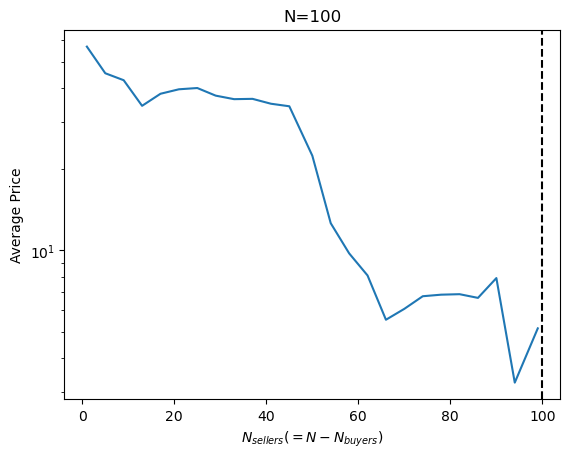

In [11]:
plt.plot(NA_list, pavg_list)
plt.axvline(N, c='k', ls='--')
#plt.xscale('log')
plt.yscale('log')
plt.xlabel('$N_{sellers} (=N - N_{buyers})$')
plt.ylabel('Average Price')
plt.title(f'N={N}')

In [12]:
MEavg = np.mean(np.array(ME_list)[:, :, 0], axis=1)
QEavg = np.mean(np.array(QE_list)[:, :, 0], axis=1)


Text(0.5, 1.0, 'N=100')

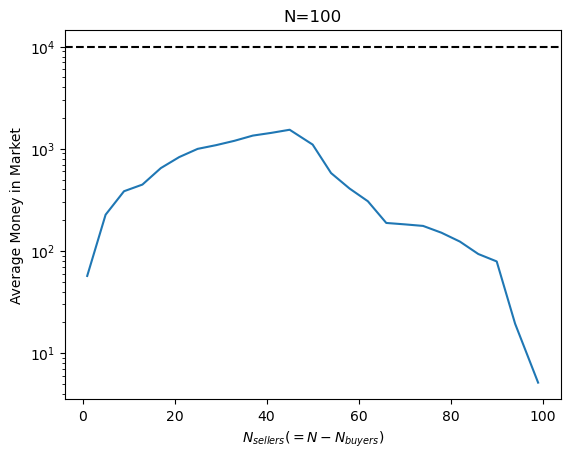

In [13]:
plt.plot(NA_list, MEavg)
plt.axhline(M*N, c='k', ls='--')
plt.yscale('log')
plt.xlabel('$N_{sellers} (=N - N_{buyers})$')
plt.ylabel('Average Money in Market')
plt.title(f'N={N}')

Text(0.5, 1.0, 'N=100')

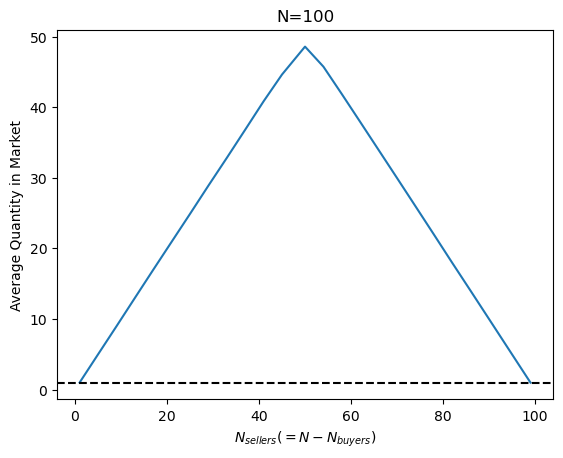

In [14]:
plt.plot(NA_list, QEavg)
plt.axhline(supply, c='k', ls='--')
#plt.yscale('log')
plt.xlabel('$N_{sellers} (=N - N_{buyers})$')
plt.ylabel('Average Quantity in Market')
plt.title(f'N={N}')

In [15]:
assert False

AssertionError: 